<a href="https://colab.research.google.com/github/awildt01/Credit-Scoring/blob/main/notebooks/8_EAD_model_estimation_and_interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EAD model

In diesem Notizbuch ist es mein Ziel, zusätzlich zum **PD-Modell** die Modelle **„Exposure at Default“ (EAD)** und „**Loss Given Default“ (LGD)** zu erstellen und **den erwarteten Verlust (EL = PD * EAD * LGD)** für jeden Kredit zu schätzen. Sobald diese drei Komponenten geschätzt sind, werde ich eine Kreditpolitik formulieren, die auf der Grundlage dieser Ergebnisse über die Genehmigung oder Ablehnung von Krediten entscheidet. Diese Aufgaben entsprechen den Schritten 3, 4 und 5 des CRISP-DM-Rahmenwerks. Die Gründe für jede Entscheidung werden im Folgenden näher erläutert.

### Estimation and Interpretation

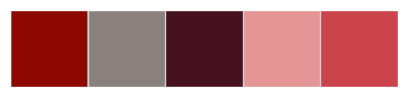

In [16]:
# Data manipulation.
import pandas as pd
import numpy as np

# Modeling.
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import scipy.stats as stat

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Display options.
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

# Visualization Settings
mpl.style.use('ggplot')
mpl.rcParams['axes.facecolor']      = 'white'
mpl.rcParams['grid.color']          = 'lightgray'
mpl.rcParams['xtick.color']         = 'black'
mpl.rcParams['ytick.color']         = 'black'
mpl.rcParams['axes.grid']           = True
#mpl.rcParams['figure.dpi']          = 150

# Palette Seting
instyle_palette = ['#8d0801', '#8a817c', '#461220', '#e39695', '#cc444b']
sns.set_palette(sns.color_palette(instyle_palette))
sns.palplot(sns.color_palette(instyle_palette))
sns.set()


In [17]:
from google.colab import drive
drive.mount('/content/drive')

# Der Pfad zu deiner Datei im Drive
file_path = '/content/drive/MyDrive/Lending-Club-Credit-Scoring/notebooks/loan_data_defaults.csv'

# Datei einlesen
loan_data_defaults = pd.read_csv(file_path)

# Kurze Bestätigung: Die ersten 5 Zeilen anzeigen
print("Datei erfolgreich aus Drive geladen!")
display(loan_data_defaults[['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:MORTGAGE',
'home_ownership:NONE',
'home_ownership:OTHER',
'home_ownership:OWN',
'home_ownership:RENT',
]].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datei erfolgreich aus Drive geladen!


,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT
0,0,0,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,1,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0,0,1
3,0,0,1,0,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,0,0,0,0,0,1


**Abhängige Variablen**

- Ich werde die abhängigen Variablen der **LGD- und EAD-Modelle**, die Rückzahlungsquote und den Kreditumrechnungsfaktor, visualisieren, um zu entscheiden, wie ich mit dem Modellierungsschritt fortfahren werde.
- **recovery_rate:** Dies ist unsere Zielvariable für das LGD-Modell. Obwohl LGD als der Anteil des Gesamtengagements definiert ist, der vom Kreditgeber bei Ausfall des Kreditnehmers nicht zurückgefordert werden kann, besteht ein gängiger und etablierter Ansatz bei der Modellierung darin, den Anteil des Gesamtengagements zu schätzen, der vom Kreditgeber nach Eintritt des Ausfalls zurückgefordert werden KANN, also die Rückgewinnungsquote. Somit gilt: LGD = 1 - Rückgewinnungsquote.
- **credit_conversion_factor:** Dies ist unsere Zielvariable für das EAD-Modell. Obwohl EAD als der Gesamtwert definiert ist, dem ein Kreditgeber bei Ausfall des Kreditnehmers ausgesetzt ist, besteht ein gängiger und etablierter Ansatz bei der Modellierung darin, den ausstehenden Anteil des finanzierten Betrags bei Eintritt des Ausfallereignisses zu schätzen, den Kreditumrechnungsfaktor. Somit gilt: EAD = Gesamtfinanzierungsbetrag * Kreditumrechnungsfaktor.



In [18]:
# Descriptive statistics.
loan_data_defaults[['recovery_rate', 'CCF']].describe().T

,count,mean,std,min,25%,50%,75%,max
recovery_rate,43236.0,0.060770,0.089202,0.000000,0.000000,0.029466,0.114044,1.0
CCF,43236.0,0.735952,0.200742,0.000438,0.632088,0.789908,0.888543,1.0


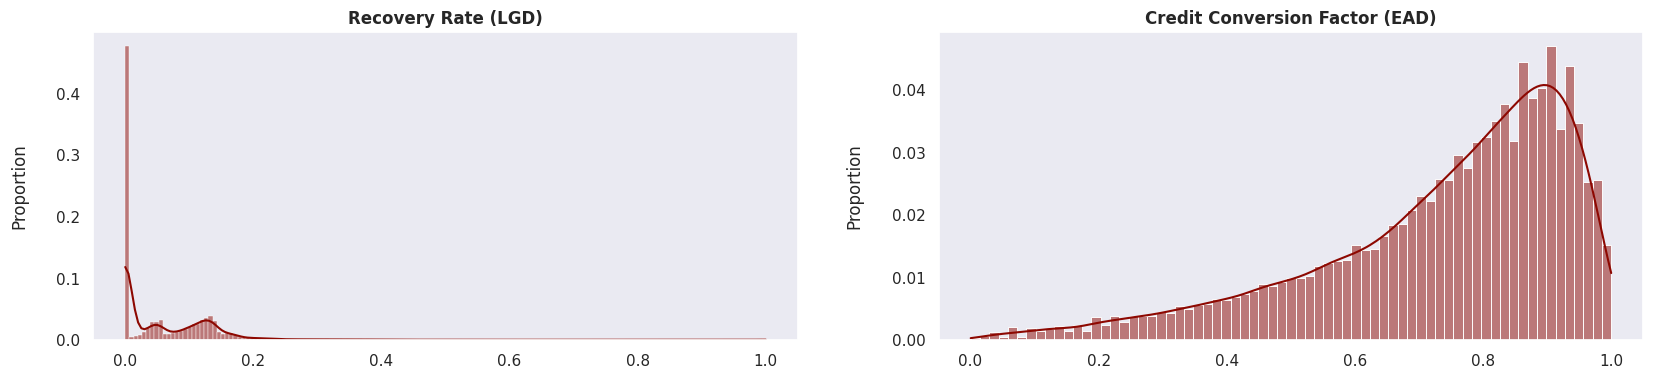

In [19]:
# Plot LGD and EAD dependent variables.
fig, ax = plt.subplots(1, 2, figsize=(20, 4))

sns.histplot(data=loan_data_defaults, x='recovery_rate', kde=True, ax=ax[0], stat='proportion', color='#8d0801')
ax[0].set_title('Recovery Rate (LGD)', fontweight='bold', fontsize=12)
ax[0].set_xlabel('')
ax[0].set_ylabel('Proportion', labelpad=20)
ax[0].grid(False)

sns.histplot(data=loan_data_defaults, x= 'CCF', kde=True, ax=ax[1], stat='proportion', color='#8d0801')
ax[1].set_title('Credit Conversion Factor (EAD)', fontweight='bold', fontsize=12)
ax[1].set_xlabel('')
ax[1].set_ylabel('Proportion', labelpad=20)
ax[1].grid(False)

Erkenntnisse:

* Es fällt auf, dass mehr als 40 % der Rückzahlungsquoten bei 0 liegen. Bei der Erstellung eines Regressionsmodells könnte eine solche Verzerrung die Leistung erheblich beeinträchtigen. Um die Rückzahlungsquote und die LGD zu modellieren, werde ich daher einen zweistufigen Ansatz verfolgen:
       

  * **In der ersten Stufe** werde ich ein logistisches Regressionsmodell erstellen, um zu klassifizieren, ob die Rückzahlungsquote 0 oder größer als 0 ist. Für die als Null klassifizierten Rückzahlungen ist der Prozess damit abgeschlossen. Für die als größer als 0 klassifizierten Rückzahlungen werde ich ein Regressionsmodell erstellen, um ihre Werte vorherzusagen, was die zweite Stufe der LGD-Modellierung darstellt.




* Für den Kreditumrechnungsfaktor haben wir eine ausgewogenere Verteilung. Daher ist ein Regressionsmodell ausreichend.
* Ich werde das Ziel für den Ansatz der ersten Stufe des LGD-Modells erstellen. Es handelt sich um eine binäre Variable, die 0 angibt, wenn die Rückzahlungsquote 0 ist, und 1, wenn die Rückzahlungsquote größer als Null ist.

Übersetzt mit DeepL.com (kostenlose Version)

In [20]:
# Create the target for the two-stage approach LGD modeling.
loan_data_defaults['recovery_rate_>0'] = np.where(loan_data_defaults['recovery_rate'] == 0, 0, 1)
loan_data_defaults['recovery_rate_>0'].value_counts(normalize=True)

,proportion
recovery_rate_>0,
1,0.563674
0,0.436326


- Lending Club konnte einen Teil der Verluste aus etwa **56,3 %** der ausgefallenen Kredite wieder hereinholen.

In [21]:
features_all = ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:MORTGAGE',
'home_ownership:NONE',
'home_ownership:OTHER',
'home_ownership:OWN',
'home_ownership:RENT',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:car',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:educational',
'purpose:home_improvement',
'purpose:house',
'purpose:major_purchase',
'purpose:medical',
'purpose:moving',
'purpose:other',
'purpose:renewable_energy',
'purpose:small_business',
'purpose:vacation',
'purpose:wedding',
'initial_list_status:f',
'initial_list_status:w',
'term_int',
'emp_length_int',
'mths_since_issue_d',
'mths_since_earliest_cr_line',
'funded_amnt',
'int_rate',
'installment',
'annual_inc',
'dti',
'delinq_2yrs',
'inq_last_6mths',
'mths_since_last_delinq',
'mths_since_last_record',
'open_acc',
'pub_rec',
'total_acc',
'acc_now_delinq',
'total_rev_hi_lim']

In [22]:
features_reference_cat = ['grade:G',
'home_ownership:RENT',
'verification_status:Verified',
'purpose:credit_card',
'initial_list_status:f']

Split the data

- Im Zusammenhang mit Krediten ist es wichtig, eine zeitliche Aufteilung anstelle einer Stichprobenaufteilung zu verwenden, da wir verstehen möchten, wie gut das mit historischen Daten trainierte Modell das Verhalten von Kreditantragstellern in der Zukunft vorhersagen kann.
- Die Daten wurden bereits bei der Datenbereinigung sortiert, sodass sie in chronologischer Reihenfolge vorliegen. Daher müssen wir nur die ersten 80 % der Daten für das Training und die restlichen 20 % für den Test trennen.
- Ich werde die Daten zuerst aufteilen, da der Testsatz Daten enthalten sollte, die das Modell zuvor noch nicht gesehen hat, um ein reales Produktionsszenario nachzuahmen. Daher lege ich sie jetzt beiseite und verwende sie erst später für die abschließende Bewertung des Modells.
- Darüber hinaus ist es entscheidend, nur die Trainingsdaten anzupassen und zu transformieren, um Probleme wie Datenlecks und Überanpassung zu vermeiden und eine zuverlässige endgültige Leistungsschätzung zu gewährleisten. Testdaten dürfen nur transformiert werden. Daher erfolgt die Vorverarbeitung nach dieser Richtlinie.

In [23]:
# EAD model datasets
ead_inputs_train, ead_inputs_test, ead_targets_train, ead_targets_test = train_test_split(loan_data_defaults.drop(['good_bad', 'recovery_rate','recovery_rate_0_1', 'CCF'], axis = 1), loan_data_defaults['CCF'], test_size = 0.2, random_state = 42)
# Takes a set of inputs and a set of targets as arguments. Splits the inputs and the targets into four dataframes:
# Inputs - Train, Inputs - Test, Targets - Train, Targets - Test.

In [24]:
print(ead_inputs_train.columns.values)

['Unnamed: 0.1' 'Unnamed: 0' 'id' 'member_id' 'loan_amnt' 'funded_amnt'
 'funded_amnt_inv' 'term' 'int_rate' 'installment' 'grade' 'sub_grade'
 'emp_title' 'emp_length' 'home_ownership' 'annual_inc'
 'verification_status' 'issue_d' 'loan_status' 'pymnt_plan' 'url' 'desc'
 'purpose' 'title' 'zip_code' 'addr_state' 'dti' 'delinq_2yrs'
 'earliest_cr_line' 'inq_last_6mths' 'mths_since_last_delinq'
 'mths_since_last_record' 'open_acc' 'pub_rec' 'revol_bal' 'revol_util'
 'total_acc' 'initial_list_status' 'out_prncp' 'out_prncp_inv'
 'total_pymnt' 'total_pymnt_inv' 'total_rec_prncp' 'total_rec_int'
 'total_rec_late_fee' 'recoveries' 'collection_recovery_fee'
 'last_pymnt_d' 'last_pymnt_amnt' 'next_pymnt_d' 'last_credit_pull_d'
 'collections_12_mths_ex_med' 'mths_since_last_major_derog' 'policy_code'
 'application_type' 'annual_inc_joint' 'dti_joint'
 'verification_status_joint' 'acc_now_delinq' 'tot_coll_amt' 'tot_cur_bal'
 'open_acc_6m' 'open_il_6m' 'open_il_12m' 'open_il_24m'
 'mths_since_r

In [26]:
import scipy.stats as stat

# Da wir eine objektorientierte Sprache wie Python verwenden, können wir einfach unsere eigene
# LinearRegression-Klasse definieren (die gleiche wie in sklearn)
# Durch Eingabe des folgenden Codes überschreiben wir einen Teil der Klasse mit einem, der p-Werte enthält.
# Hier ist der vollständige Quellcode der ORIGINAL-Klasse: https://github.com/scikit-learn/scikit-learn/blob/7b136e9/sklearn/linear_model/base.py#L362


class LinearRegression(linear_model.LinearRegression):
    """
    LinearRegression-Klasse nach sklearn, berechnet jedoch t-Statistiken
    und p-Werte für Modellkoeffizienten (Betas).
    Zusätzliche Attribute, die nach .fit() verfügbar sind,
    sind `t` und `p`, die die Form (y.shape[1], X.shape[1]) haben,
    also (n_features, n_coefs).
    Diese Klasse setzt den Schnittpunkt standardmäßig auf 0, da wir ihn normalerweise
    in X einbeziehen.
    """

    # nothing changes in __init__
    def __init__(self, fit_intercept=True, copy_X=True,
                 n_jobs=1):
        super().__init__(fit_intercept=fit_intercept, copy_X=copy_X, n_jobs=n_jobs)


    def fit(self, X, y, n_jobs=1):
        # Rufe die ursprüngliche fit-Methode aus der übergeordneten Klasse auf.
        super().fit(X, y, n_jobs)

        # Berechne SSE (Summe der quadrierten Fehler)
        # und SE (Standardfehler)
        sse = np.sum((self.predict(X) - y) ** 2, axis=0) / float(X.shape[0] - X.shape[1])
        se = np.array([np.sqrt(np.diagonal(sse * np.linalg.inv(np.dot(X.T, X))))])

        # Berechne die t-Statistik für jedes Merkmal.
        self.t = self.coef_ / se
        # Finden Sie den p-Wert für jedes Merkmal.
        self.p = np.squeeze(2 * (1 - stat.t.cdf(np.abs(self.t), y.shape[0] - X.shape[1])))
        return self

In [27]:
ead_inputs_train = ead_inputs_train[features_all]
# Here we keep only the variables we need for the model.

In [28]:
ead_inputs_train = ead_inputs_train.drop(features_reference_cat, axis = 1)
# Here we remove the dummy variable reference categories.

In [29]:
reg_ead = LinearRegression()
# We create an instance of an object from the 'LogisticRegression' class.
reg_ead.fit(ead_inputs_train, ead_targets_train)
# Estimates the coefficients of the object from the 'LogisticRegression' class
# with inputs (independent variables) contained in the first dataframe
# and targets (dependent variables) contained in the second dataframe.

LinearRegression()

In [30]:
feature_name = ead_inputs_train.columns.values

In [31]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
# Creates a dataframe with a column titled 'Feature name' and row values contained in the 'feature_name' variable.
summary_table['Coefficients'] = np.transpose(reg_ead.coef_)
# Creates a new column in the dataframe, called 'Coefficients',
# with row values the transposed coefficients from the 'LogisticRegression' object.
summary_table.index = summary_table.index + 1
# Increases the index of every row of the dataframe with 1.
summary_table.loc[0] = ['Intercept', reg_ead.intercept_]
# Assigns values of the row with index 0 of the dataframe.
summary_table = summary_table.sort_index()
# Sorts the dataframe by index.
p_values = reg_ead.p
# We take the result of the newly added method 'p_values' and store it in a variable 'p_values'.
p_values = np.append(np.nan,np.array(p_values))
# We add the value 'NaN' in the beginning of the variable with p-values.
summary_table['p_values'] = p_values
# In the 'summary_table' dataframe, we add a new column, called 'p_values', containing the values from the 'p_values' variable.
summary_table

,Feature name,Coefficients,p_values
0,Intercept,1.109746e+00,NaN
1,grade:A,-3.030033e-01,0.000000e+00
2,grade:B,-2.364277e-01,0.000000e+00
3,grade:C,-1.720232e-01,0.000000e+00
4,grade:D,-1.198470e-01,0.000000e+00
5,grade:E,-6.768713e-02,0.000000e+00
6,grade:F,-2.045907e-02,4.428795e-03
7,home_ownership:MORTGAGE,-6.343341e-03,2.632464e-03
8,home_ownership:NONE,-5.539064e-03,9.318931e-01
9,home_ownership:OTHER,-2.426052e-03,9.335820e-01


### Model Validation

In [32]:
ead_inputs_test = ead_inputs_test[features_all]
# Here we keep only the variables we need for the model.

In [33]:
ead_inputs_test = ead_inputs_test.drop(features_reference_cat, axis = 1)
# Here we remove the dummy variable reference categories.

In [34]:
ead_inputs_test.columns.values

array(['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
       'home_ownership:MORTGAGE', 'home_ownership:NONE',
       'home_ownership:OTHER', 'home_ownership:OWN',
       'verification_status:Not Verified',
       'verification_status:Source Verified', 'purpose:car',
       'purpose:debt_consolidation', 'purpose:educational',
       'purpose:home_improvement', 'purpose:house',
       'purpose:major_purchase', 'purpose:medical', 'purpose:moving',
       'purpose:other', 'purpose:renewable_energy',
       'purpose:small_business', 'purpose:vacation', 'purpose:wedding',
       'initial_list_status:w', 'term_int', 'emp_length_int',
       'mths_since_issue_d', 'mths_since_earliest_cr_line', 'funded_amnt',
       'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'total_acc',
       'acc_now_delinq', 'total_rev_hi_lim'], dtype=object)

In [35]:
y_hat_test_ead = reg_ead.predict(ead_inputs_test)
# Calculates the predicted values for the dependent variable (targets)
# based on the values of the independent variables (inputs) supplied as an argument.

In [36]:
ead_targets_test_temp = ead_targets_test

In [37]:
ead_targets_test_temp = ead_targets_test_temp.reset_index(drop = True)
# We reset the index of a dataframe.

In [38]:
pd.concat([ead_targets_test_temp, pd.DataFrame(y_hat_test_ead)], axis = 1).corr()
# We calculate the correlation between actual and predicted values.

,CCF,0
CCF,1.000000,0.530654
0,0.530654,1.000000


<Axes: xlabel='CCF', ylabel='Density'>

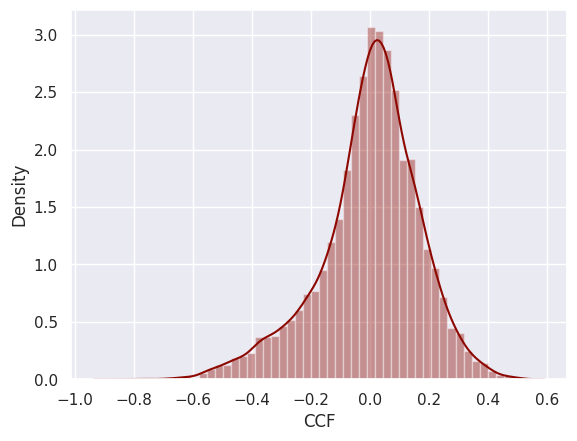

In [43]:
sns.distplot(ead_targets_test - y_hat_test_ead, color='#8d0801')
# We plot the distribution of the residuals.

In [40]:
pd.DataFrame(y_hat_test_ead).describe()
# Shows some descriptive statisics for the values of a column.

,0
count,8648.000000
mean,0.736013
std,0.105194
min,0.384774
25%,0.661553
50%,0.731750
75%,0.810625
max,1.161088


In [41]:
y_hat_test_ead = np.where(y_hat_test_ead < 0, 0, y_hat_test_ead)
y_hat_test_ead = np.where(y_hat_test_ead > 1, 1, y_hat_test_ead)
# We set predicted values that are greater than 1 to 1 and predicted values that are less than 0 to 0.

In [42]:
pd.DataFrame(y_hat_test_ead).describe()
# Shows some descriptive statisics for the values of a column.

,0
count,8648.000000
mean,0.735992
std,0.105127
min,0.384774
25%,0.661553
50%,0.731750
75%,0.810625
max,1.000000
